# ABSA Dataset Exploration

This notebook explores and profiles the dataset for Aspect-Based Sentiment Analysis (ABSA).

**Goals:**
- Understand dataset structure and quality
- Analyze text characteristics (length, complexity)
- Identify potential aspects and sentiment patterns
- Discover challenges (negations, multi-aspect sentences)
- Inform design decisions for the three ABSA implementations

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# NLP libraries for analysis
import spacy
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


# Configuration
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Initialize NLP tools
nlp = spacy.load("en_core_web_sm")
vader = SentimentIntensityAnalyzer()



## 1. Dataset Loading and Basic Inspection

Load the dataset and examine its structure, size, and basic properties.

In [2]:
try:
    with open('../data/yelp_sample.json', 'r', encoding='utf-8') as f:
        data = json.load(f)
    df = pd.DataFrame(data, columns=['text'])
    print(" Loaded JSON dataset successfully")
except FileNotFoundError:
    print(" File not found - please check the file path")
    df = pd.DataFrame()

print(f"\nDataset Overview:")
print(f"  • Shape: {df.shape}")
print(f"  • Columns: {df.columns.tolist()}")

 Loaded JSON dataset successfully

Dataset Overview:
  • Shape: (50, 1)
  • Columns: ['text']


## Remove duplicates



In [3]:
initial_count = len(df)
df = df.drop_duplicates(subset='text', keep='first')
duplicates_removed = initial_count - len(df)

if duplicates_removed > 0:
    print(f"  • Removed {duplicates_removed} duplicate reviews")

print(f"\nFirst few reviews:")
display(df.head())


First few reviews:


,text
0,Many Healthy options available. Food is always...
1,They really worked with us to remedy a sales e...
2,"I love this cinema. Before the movie starts, ..."
3,Great sandwich and soup combo. We had a party ...
4,Hands down the BEST Mexican in town. Please g...


## 2. Text Statistics

Analyze basic text properties: length, sentence structure, word counts.

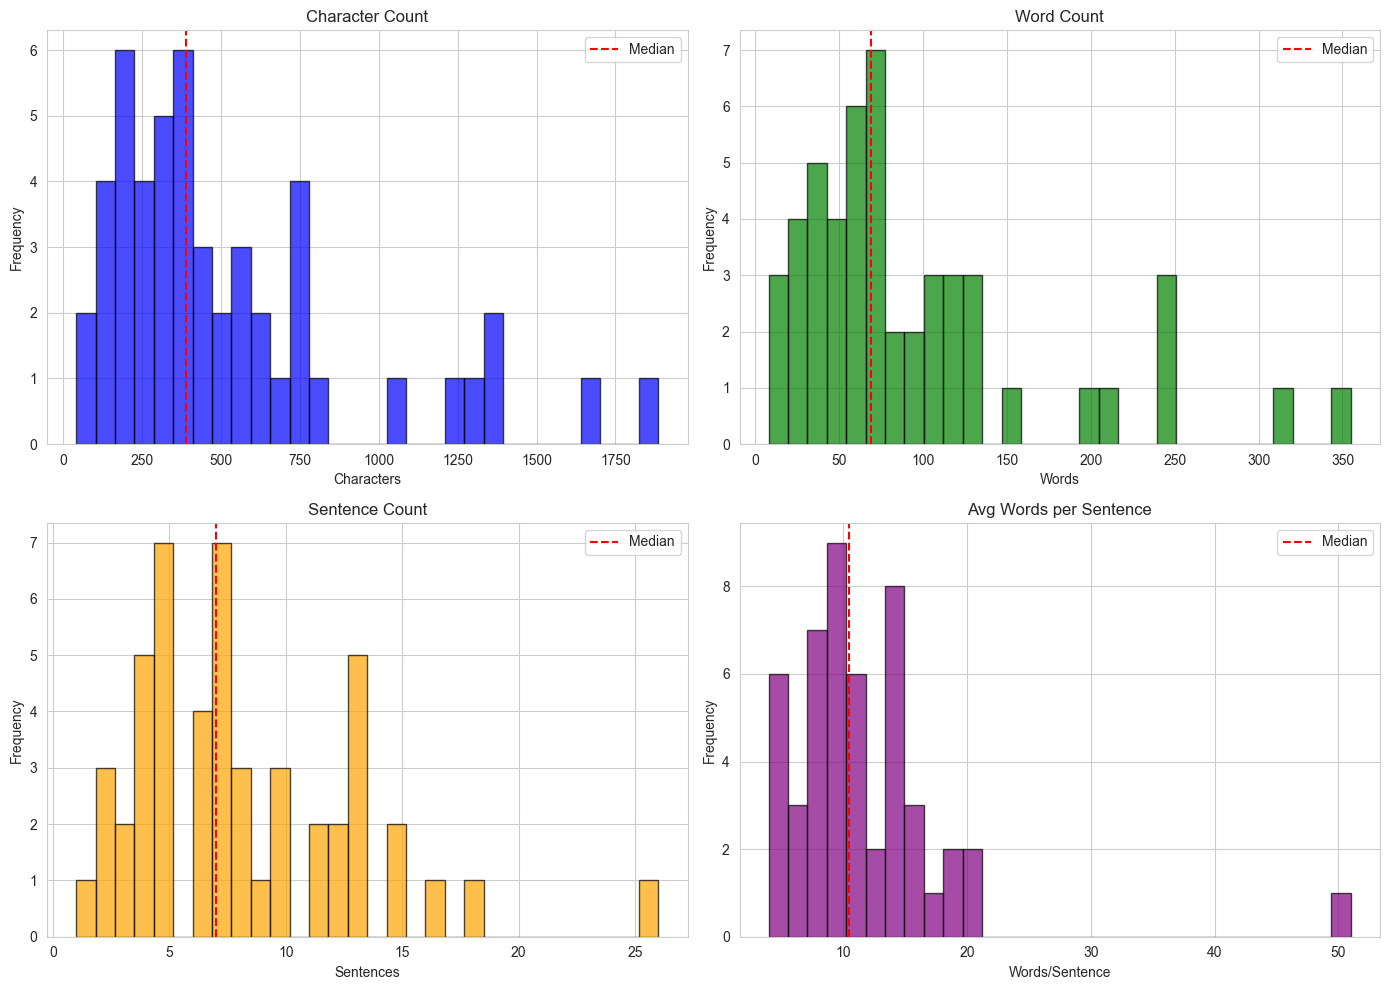

Text Statistics Summary:
  • Average review length: 95.4 words
  • Median sentences per review: 7
  • Average sentence complexity: 11.8 words/sentence
  • Character range: 41-1886


In [4]:
df['char_count'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()
df['sentence_count'] = df['text'].str.count(r'[.!?]') + 1
df['avg_words_per_sentence'] = df['word_count'] / df['sentence_count']

# Visualize distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_config = [
    ('char_count', 'Character Count', 'blue', 'Characters'),
    ('word_count', 'Word Count', 'green', 'Words'),
    ('sentence_count', 'Sentence Count', 'orange', 'Sentences'),
    ('avg_words_per_sentence', 'Avg Words per Sentence', 'purple', 'Words/Sentence')
]

for idx, (col, title, color, xlabel) in enumerate(metrics_config):
    ax = axes[idx // 2, idx % 2]
    ax.hist(df[col], bins=30, edgecolor='black', alpha=0.7, color=color)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Frequency')
    ax.axvline(df[col].median(), color='red', linestyle='--', label='Median')
    ax.legend()

plt.tight_layout()
plt.show()

# Print insights
print("Text Statistics Summary:")
print(f"  • Average review length: {df['word_count'].mean():.1f} words")
print(f"  • Median sentences per review: {df['sentence_count'].median():.0f}")
print(f"  • Average sentence complexity: {df['avg_words_per_sentence'].mean():.1f} words/sentence")
print(f"  • Character range: {df['char_count'].min():.0f}-{df['char_count'].max():.0f}")

## 3. Linguistic Analysis with spaCy

Use spaCy to extract linguistic features relevant for ABSA:
- Part-of-speech (POS) distribution
- Noun phrases (potential aspects)
- Adjectives (potential opinion words)

In [5]:
sample_size = min(100, len(df))
sample_texts = df['text'].sample(sample_size, random_state=42).tolist()

print(f"Processing {sample_size} reviews with spaCy...")

pos_counts = Counter()
all_nouns = []
all_adjectives = []
noun_chunks = []

for doc in nlp.pipe(sample_texts, batch_size=50):
    for token in doc:
        pos_counts[token.pos_] += 1
        if token.pos_ == 'NOUN':
            all_nouns.append(token.lemma_.lower())
        elif token.pos_ == 'ADJ':
            all_adjectives.append(token.lemma_.lower())

    for chunk in doc.noun_chunks:
        noun_chunks.append(chunk.text.lower())

print("Processing  complete")

Processing 50 reviews with spaCy...
Processing  complete


#### Visualize POS distribution

C:\Users\edobo\AppData\Local\Temp\ipykernel_24412\1381154352.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pos_df, x='POS', y='Count', palette='viridis')


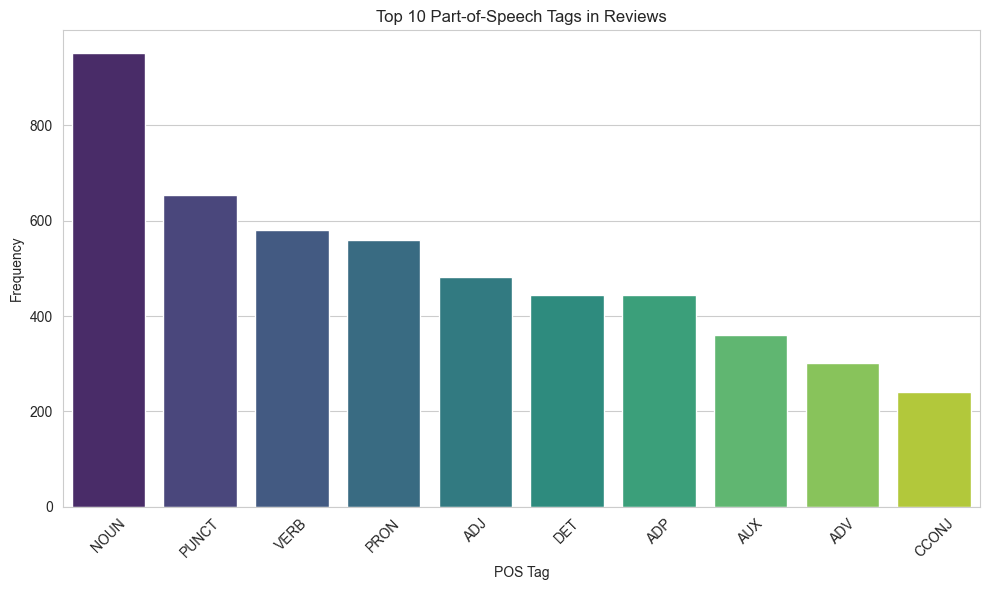


 POS Distribution:
 Total tokens analyzed: 5,650
 Nouns: 951 (16.8%)
 Adjectives: 481 (8.5%)
 Verbs: 581 (10.3%)


In [6]:
pos_df = pd.DataFrame(pos_counts.most_common(10), columns=['POS', 'Count'])

plt.figure(figsize=(10, 6))
sns.barplot(data=pos_df, x='POS', y='Count', palette='viridis')
plt.title('Top 10 Part-of-Speech Tags in Reviews')
plt.xlabel('POS Tag')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\n POS Distribution:")
print(f" Total tokens analyzed: {sum(pos_counts.values()):,}")
print(f" Nouns: {pos_counts['NOUN']:,} ({100*pos_counts['NOUN']/sum(pos_counts.values()):.1f}%)")
print(f" Adjectives: {pos_counts['ADJ']:,} ({100*pos_counts['ADJ']/sum(pos_counts.values()):.1f}%)")
print(f" Verbs: {pos_counts['VERB']:,} ({100*pos_counts['VERB']/sum(pos_counts.values()):.1f}%)")

## 4. Aspect Vocabulary Analysis

Identify the most common nouns and noun phrases that likely represent aspects.

🎯 Top 20 Most Common Nouns (Potential Aspects):
  place                :   29
  time                 :   21
  food                 :   15
  service              :   11
  night                :   11
  room                 :   11
  staff                :   11
  dog                  :    9
  wife                 :    9
  restaurant           :    9
  menu                 :    8
  coffee               :    8
  order                :    7
  day                  :    7
  owner                :    7
  nail                 :    7
  price                :    6
  lot                  :    6
  hour                 :    6
  location             :    5


C:\Users\edobo\AppData\Local\Temp\ipykernel_24412\553296465.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=noun_df, y='Noun', x='Frequency', palette='Blues_r')


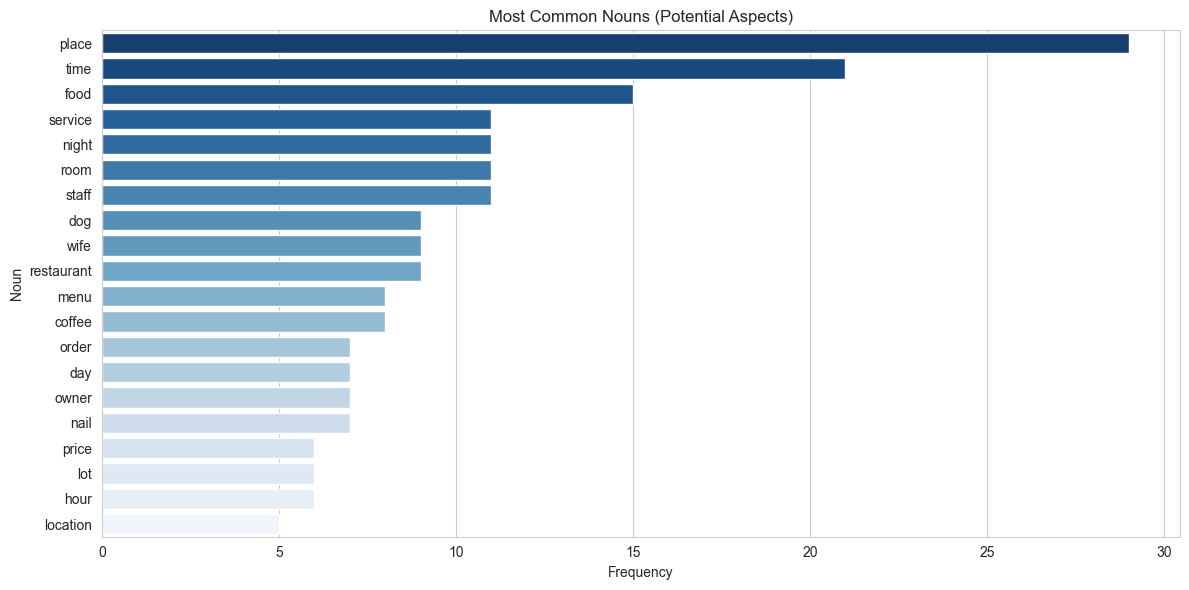


🔗 Multi-word Aspects Found: 4
  this place                     :   16
  the food                       :    6
  my wife                        :    6
  the staff                      :    5


In [7]:
# Most common nouns (potential aspects)
noun_counter = Counter(all_nouns)
top_nouns = noun_counter.most_common(20)
chunk_counter = Counter(noun_chunks)
top_chunks = chunk_counter.most_common(20)

print("🎯 Top 20 Most Common Nouns (Potential Aspects):")
for noun, count in top_nouns:
    print(f"  {noun:20} : {count:4d}")

# Visualize top nouns
noun_df = pd.DataFrame(top_nouns, columns=['Noun', 'Frequency'])
plt.figure(figsize=(12, 6))
sns.barplot(data=noun_df, y='Noun', x='Frequency', palette='Blues_r')
plt.title('Most Common Nouns (Potential Aspects)')
plt.tight_layout()
plt.show()

multi_word_chunks = [(c, cnt) for c, cnt in top_chunks if len(c.split()) > 1]
if multi_word_chunks:
    print(f"\n🔗 Multi-word Aspects Found: {len(multi_word_chunks)}")
    for chunk, count in multi_word_chunks[:10]:
        print(f"  {chunk:30} : {count:4d}")

## 5. Opinion Word Analysis


 Top 20 Most Common Adjectives (Opinion Words):
  good                 :   29
  great                :   16
  fresh                :   14
  friendly             :   12
  little               :   11
  new                  :   10
  other                :    9
  nice                 :    9
  more                 :    9
  excellent            :    7
  available            :    6
  high                 :    6
  delicious            :    5
  few                  :    5
  hot                  :    5
  bad                  :    5
  happy                :    4
  helpful              :    4
  first                :    4
  amazing              :    4


C:\Users\edobo\AppData\Local\Temp\ipykernel_24412\487435609.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=adj_df, x='Adjective', y='Frequency', palette='Reds_r')


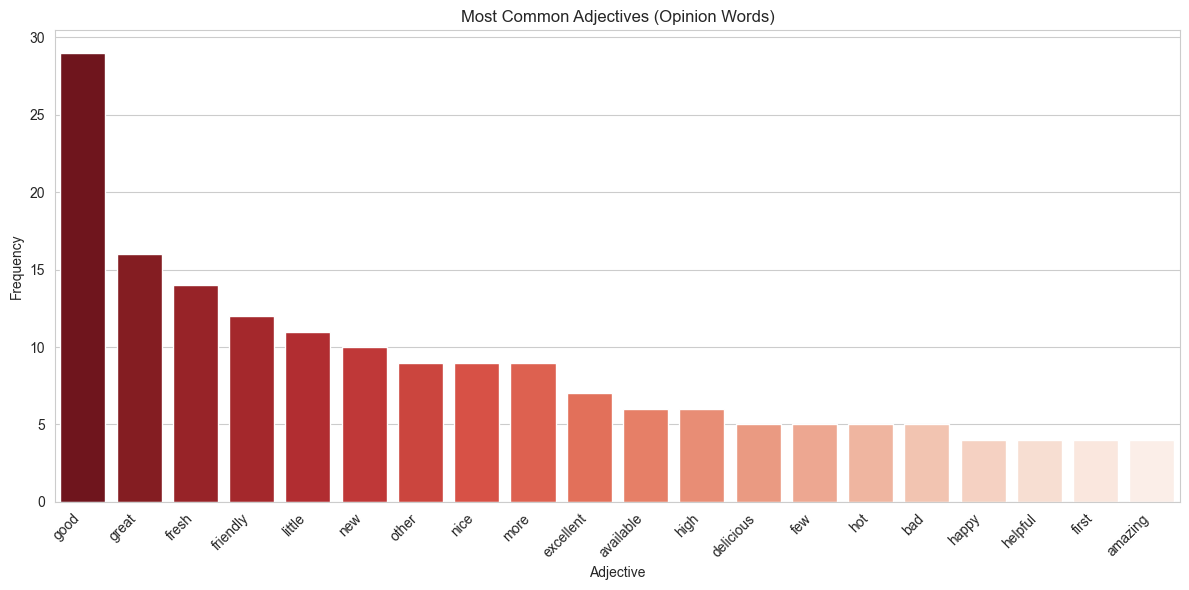

In [8]:
adj_counter = Counter(all_adjectives)
top_adjectives = adj_counter.most_common(20)
print(" Top 20 Most Common Adjectives (Opinion Words):")
for adj, count in top_adjectives:
        print(f"  {adj:20} : {count:4d}")
# Visualize
adj_df = pd.DataFrame(top_adjectives, columns=['Adjective', 'Frequency'])
plt.figure(figsize=(12, 6))
sns.barplot(data=adj_df, x='Adjective', y='Frequency', palette='Reds_r')
plt.title('Most Common Adjectives (Opinion Words)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6. Sentiment Distribution

In [9]:
# Calculate sentiment scores
df['vader_scores'] = df['text'].apply(vader.polarity_scores)
df['sentiment_score'] = df['vader_scores'].apply(lambda x: x['compound'])

# Classify sentiments
def classify_sentiment(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df['sentiment_label'] = df['sentiment_score'].apply(classify_sentiment)

# Display distribution
sentiment_counts = df['sentiment_label'].value_counts()
print("✓ Sentiment analysis complete")

print(f"\n Sentiment Distribution:")
for label, count in sentiment_counts.items():
    pct = 100 * count / len(df)
    print(f"  • {label.capitalize()}: {count} reviews ({pct:.1f}%)")

✓ Sentiment analysis complete

 Sentiment Distribution:
  • Positive: 43 reviews (86.0%)
  • Negative: 6 reviews (12.0%)
  • Neutral: 1 reviews (2.0%)


## 7. Challenge Analysis: Negation & Contrasts

In [10]:
# Negation analysis
negation_words = ['not', 'no', 'never', 'nothing', 'nowhere', 'neither',
                  'nobody', 'none', "n't", 'hardly', 'barely', 'scarcely']

def count_negations(text):
    text_lower = text.lower()
    return sum(1 for word in negation_words if f" {word} " in f" {text_lower} ")

df['negation_count'] = df['text'].apply(count_negations)
df['has_negation'] = df['negation_count'] > 0

# Contrastive analysis
contrastive_words = ['but', 'however', 'although', 'though', 'yet', 'whereas']
df['has_contrastive'] = df['text'].apply(
    lambda x: any(f" {word} " in f" {x.lower()} " for word in contrastive_words)
)

print("⚡ Challenge Analysis:")
print(f"  • Reviews with negations: {df['has_negation'].sum()} ({df['has_negation'].mean()*100:.1f}%)")
print(f"  • Reviews with contrastive structures: {df['has_contrastive'].sum()} ({df['has_contrastive'].mean()*100:.1f}%)")
print(f"  • Average negations per review: {df['negation_count'].mean():.2f}")

⚡ Challenge Analysis:
  • Reviews with negations: 27 (54.0%)
  • Reviews with contrastive structures: 15 (30.0%)
  • Average negations per review: 0.68


## 8. Domain Analysis

 Detecting domains...
✓ Domain detection complete

🌐 Domain Distribution:
  • restaurant  : 26 reviews (52.0%)
  • other       :  7 reviews (14.0%)
  • service     :  5 reviews (10.0%)
  • retail      :  5 reviews (10.0%)
  • gym         :  3 reviews (6.0%)
  • salon       :  3 reviews (6.0%)
  • cinema      :  1 reviews (2.0%)


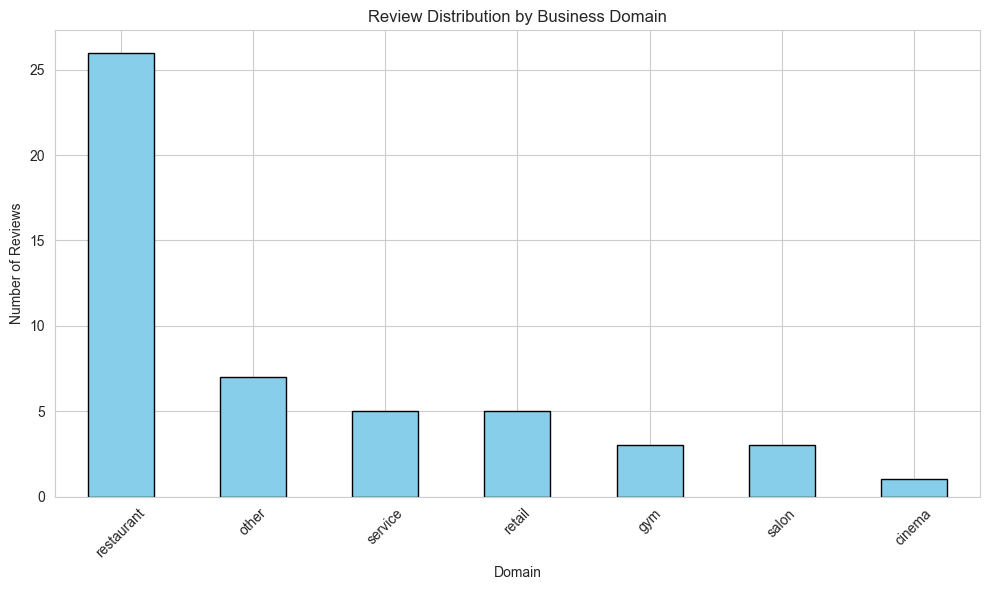

In [11]:
DOMAIN_KEYWORDS = {
    'restaurant': ['restaurant', 'food', 'menu', 'pizza', 'burger', 'meal', 'dinner', 'lunch'],
    'gym': ['gym', 'workout', 'exercise', 'fitness', 'trainer', 'class', 'work out'],
    'salon': ['salon', 'hair', 'nail', 'stylist', 'manicure', 'pedicure', 'cut', 'color'],
    'cinema': ['movie', 'film', 'cinema', 'theater', 'screen', 'showtime', 'ticket'],
    'retail': ['store', 'shop', 'product', 'buy', 'purchase', 'price', 'cost'],
    'service': ['service', 'install', 'installation', 'company', 'contractor', 'quote']
}

def detect_domain(text):
    """Detect business domain based on keyword matching."""
    text_lower = text.lower()
    domain_scores = {}

    for domain, keywords in DOMAIN_KEYWORDS.items():
        score = sum(1 for keyword in keywords if keyword in text_lower)
        if score > 0:
            domain_scores[domain] = score

    return max(domain_scores.items(), key=lambda x: x[1])[0] if domain_scores else 'other'

# Apply domain detection
print(" Detecting domains...")
df['domain'] = df['text'].apply(detect_domain)

# Display domain distribution
domain_counts = df['domain'].value_counts()
print("✓ Domain detection complete")

print(f"\n🌐 Domain Distribution:")
for domain, count in domain_counts.items():
    pct = 100 * count / len(df)
    print(f"  • {domain:12}: {count:2d} reviews ({pct:.1f}%)")

# Visualize
plt.figure(figsize=(10, 6))
domain_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Review Distribution by Business Domain')
plt.xlabel('Domain')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 9.  Domain-Specific Analysis


In [12]:
# Analyze challenges by domain
domain_analysis = []
for domain in df['domain'].unique():
    domain_df = df[df['domain'] == domain]
    if len(domain_df) > 0:
        domain_analysis.append({
            'domain': domain,
            'count': len(domain_df),
            'avg_words': domain_df['word_count'].mean(),
            'negation_rate': domain_df['has_negation'].mean() * 100,
            'contrastive_rate': domain_df['has_contrastive'].mean() * 100,
        })

challenge_df = pd.DataFrame(domain_analysis)

print("\n📊 Domain-Specific Challenges:")
print("=" * 65)
print(f"{'Domain':12} {'Reviews':8} {'Avg Words':10} {'Negation%':10} {'Contrast%':10}")
print("-" * 65)

for _, row in challenge_df.iterrows():
    print(f"{row['domain']:12} {row['count']:8.0f} {row['avg_words']:10.1f} "
          f"{row['negation_rate']:10.1f} {row['contrastive_rate']:10.1f}")

# Find most challenging domains
if not challenge_df.empty:
    most_negation = challenge_df.loc[challenge_df['negation_rate'].idxmax()]
    most_contrast = challenge_df.loc[challenge_df['contrastive_rate'].idxmax()]

    print(f"\n Key Findings:")
    print(f"  • Highest negation rate: {most_negation['domain']} ({most_negation['negation_rate']:.1f}%)")
    print(f"  • Highest contrast rate: {most_contrast['domain']} ({most_contrast['contrastive_rate']:.1f}%)")


📊 Domain-Specific Challenges:
Domain       Reviews  Avg Words  Negation%  Contrast% 
-----------------------------------------------------------------
restaurant         26       99.4       50.0       30.8
service             5      121.4       60.0       20.0
cinema              1       86.0      100.0        0.0
other               7       54.3       57.1       14.3
gym                 3      161.3       66.7       66.7
retail              5       46.2       40.0       20.0
salon               3      133.3       66.7       66.7

 Key Findings:
  • Highest negation rate: cinema (100.0%)
  • Highest contrast rate: gym (66.7%)


### 10. Implementation Insights & Recommendations

In [13]:
print("=" * 70)
print("IMPLEMENTATION INSIGHTS & RECOMMENDATIONS")
print("=" * 70)

print(f"\n DATASET OVERVIEW:")
print(f"  • Total reviews: {len(df)}")
print(f"  • Average length: {df['word_count'].mean():.1f} words")
print(f"  • Domains covered: {len(df['domain'].unique())}")

print(f"\n SENTIMENT DISTRIBUTION:")
for label, count in df['sentiment_label'].value_counts().items():
    pct = 100 * count / len(df)
    print(f"  • {label.capitalize()}: {count} reviews ({pct:.1f}%)")

print(f"\n  CHALLENGES IDENTIFIED:")
print(f" Negations: {df['has_negation'].sum()} reviews ({df['has_negation'].mean()*100:.1f}%)")
print(f" Contrastive structures: {df['has_contrastive'].sum()} reviews ({df['has_contrastive'].mean()*100:.1f}%)")
print(f" Top aspects: {', '.join([n for n, _ in top_nouns[:3]])}")
print("\n" + "=" * 70)

IMPLEMENTATION INSIGHTS & RECOMMENDATIONS

 DATASET OVERVIEW:
  • Total reviews: 50
  • Average length: 95.4 words
  • Domains covered: 7

 SENTIMENT DISTRIBUTION:
  • Positive: 43 reviews (86.0%)
  • Negative: 6 reviews (12.0%)
  • Neutral: 1 reviews (2.0%)

  CHALLENGES IDENTIFIED:
 Negations: 27 reviews (54.0%)
 Contrastive structures: 15 reviews (30.0%)
 Top aspects: place, time, food

